# pyfcfc quick start: correlation functions in a periodic box

`pyfcfc` wraps the C code [FCFC](https://github.com/cheng-zhao/FCFC) so that
pair counts and correlation functions can be computed from NumPy arrays,
with OpenMP parallelism and (optionally) SIMD vectorisation.

In this notebook you will:

1. inspect the result dictionary of a pair-counting run,
2. compute the isotropic $\xi(s)$, the multipoles $\xi_{0,2,4}(s)$ and the
   projected correlation function $w_p(s_\perp)$ of a mock clustered
   catalogue in a periodic box,
3. understand the pair-count conventions and normalizations.

Companion notebooks: `02_survey_and_pycorr.ipynb` (survey-like data and the
pycorr interoperability) and `03_benchmarking.ipynb` (performance).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.path.abspath(''), 'examples'))
sys.path.insert(0, os.path.join(os.path.abspath(''), os.pardir, 'examples'))
%matplotlib inline

import pyfcfc
from pyfcfc.boxes import py_compute_cf, simd_info
from pyfcfc.utils import compute_multipoles, compute_wp
print('pyfcfc', pyfcfc.__version__, '| SIMD build:', simd_info()[1],
      '| OMP threads:', os.environ.get('OMP_NUM_THREADS', 'unset'))

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


pyfcfc 0.2.0 | SIMD build: none | OMP threads: 2


## 1. A mock catalogue

We build a periodic-box catalogue with Gaussian clumps on top of a uniform
component (so that $\xi \neq 0$), plus a uniform random catalogue.
`examples/mocks.py` ships with the repository.

In [2]:
from mocks import make_clustered_box
BOX = 1000.
data, w_data = make_clustered_box(30000, BOX, seed=42)
rand, w_rand = make_clustered_box(60000, BOX, seed=7, n_centers=1, clump_frac=0.)
print(data.shape, w_data.shape)

(30000, 3) (30000,)


## 2. The result dictionary

Everything FCFC computes comes back in one plain dictionary. Positions and
weights are *copied* internally — your arrays are never modified.

In [3]:
s_edges = np.arange(0, 151, 5.)
res = py_compute_cf([data, rand], [w_data, w_rand], s_edges, None, 40,
                    label=['D', 'R'],        # catalogue labels
                    bin=1,                    # 0: iso | 1: (s,mu) | 2: (s_perp,pi)
                    pair=['DD', 'DR', 'RR'],  # pair counts to evaluate
                    cf=['(DD - 2 * DR + RR) / RR'],   # Landy-Szalay
                    multipole=[0, 2, 4],
                    box=BOX)
for k in sorted(res):
    v = res[k]
    print(f'{k:16s}', np.shape(v) if isinstance(v, np.ndarray) else type(v).__name__)

cf               (1, 30, 40)
labels           list
multipoles       (1, 3, 30)
normalization    dict
number           dict
pairs            dict
poles            list
s                (30,)
weighted_number  dict


In [4]:
# raw (weighted) pair counts = normalized counts x normalization
DD_raw = res['pairs']['DD'] * res['normalization']['DD']
print('ordered DD pairs in bins:', DD_raw.sum())
print('normalization DD = (sum w)^2 - sum w^2 ?',
      np.isclose(res['normalization']['DD'], w_data.sum()**2 - (w_data**2).sum()))
print('weighted_number = sum w ?',
      np.isclose(res['weighted_number']['D'], w_data.sum()))

ordered DD pairs in bins: 18407999.6504424
normalization DD = (sum w)^2 - sum w^2 ? True
weighted_number = sum w ? True


## 3. Multipoles

`res['multipoles']` holds FCFC's internal (midpoint-rule) integration of
the estimator; `pyfcfc.utils.compute_multipoles` can re-integrate the raw
$\xi(s,\mu)$ with either FCFC's scheme or pycorr's exact scheme.

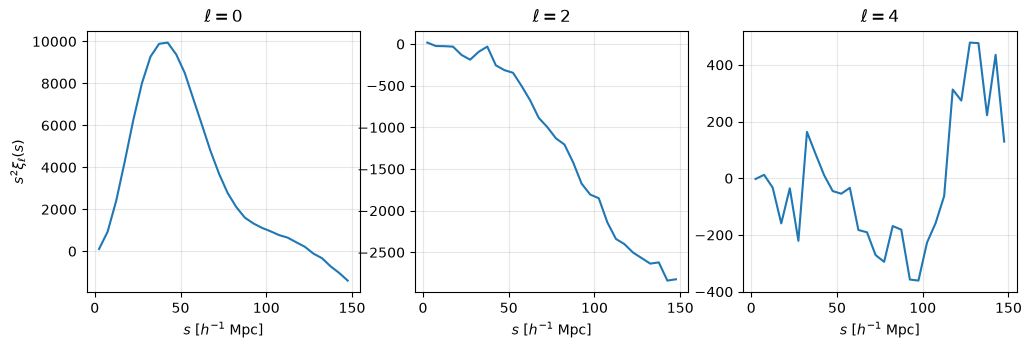

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for i, ell in enumerate((0, 2, 4)):
    axes[i].plot(res['s'], res['s']**2 * res['multipoles'][0, i])
    axes[i].set_title(f'$\ell={ell}$'); axes[i].grid(alpha=.3)
    axes[i].set_xlabel(r'$s$ [$h^{-1}$ Mpc]')
axes[0].set_ylabel(r'$s^2\xi_\ell(s)$');

## 4. Isotropic $\xi(s)$ and projected $w_p(s_\perp)$

w_p from utils.compute_wp matches FCFC internal integration


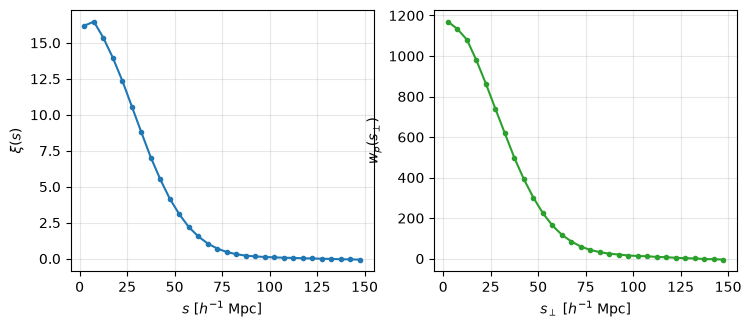

In [6]:
res_iso = py_compute_cf([data, rand], [w_data, w_rand], s_edges, None, 0,
                        label=['D', 'R'], bin=0, pair=['DD', 'DR', 'RR'],
                        cf=['(DD - 2 * DR + RR) / RR'], box=BOX)
pi_edges = np.linspace(0, 80, 17)
res_wp = py_compute_cf([data, rand], [w_data, w_rand], s_edges, pi_edges, 0,
                       label=['D', 'R'], bin=2, pair=['DD', 'DR', 'RR'],
                       cf=['(DD - 2 * DR + RR) / RR'], wp=True, box=BOX)
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
axes[0].plot(res_iso['s'], res_iso['cf'][0], '-o', ms=3)
axes[0].set_xlabel(r'$s$ [$h^{-1}$ Mpc]'); axes[0].set_ylabel(r'$\xi(s)$'); axes[0].grid(alpha=.3)
axes[1].plot(res_wp['s'], res_wp['projected'][0], '-o', ms=3, color='C2')
axes[1].set_xlabel(r'$s_\perp$ [$h^{-1}$ Mpc]'); axes[1].set_ylabel(r'$w_p(s_\perp)$'); axes[1].grid(alpha=.3)
# cross-check with the utilities
assert np.allclose(compute_wp(res_wp['cf'][0], pi_edges), res_wp['projected'][0])
print('w_p from utils.compute_wp matches FCFC internal integration')

### The 2D correlation function $\xi(s_\perp, \pi)$
The same (s_perp, pi) run also returns the full 2D correlation function
in `res_wp['cf']` (shape `(ncf, ns, np)`); `res_wp['projected']` is its
pi-integration, $w_p(s_\perp)$.

xi2d shape: (30, 16) | max: 16.646255857019337


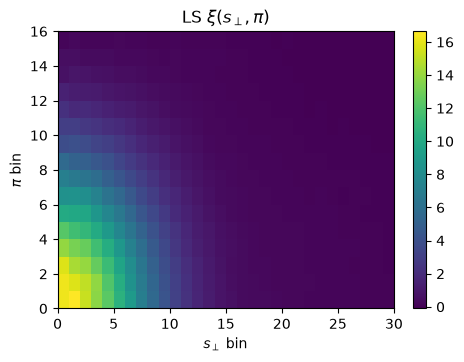

In [7]:
fig, ax = plt.subplots(figsize=(4.8, 3.6))
im = ax.pcolormesh(res_wp['cf'][0].T, shading='auto', cmap='viridis')
ax.set_xlabel(r'$s_\perp$ bin'); ax.set_ylabel(r'$\pi$ bin')
ax.set_title(r'LS $\xi(s_\perp, \pi)$')
fig.colorbar(im, ax=ax, fraction=0.046)
print('xi2d shape:', res_wp['cf'][0].shape, '| max:', res_wp['cf'][0].max())

## 5. Conventions cheat-sheet

* auto pairs are counted **twice** (ordered), normalization $(\sum w)^2-\sum w^2$;
* cross pairs once per combination, normalization $\sum w_1 \sum w_2$;
* only $\mu\ge 0$ (or $\pi \ge 0$) is binned, with absolute values;
* bins are left-closed, right-open;
* unit weights activate the exact integer counting path automatically.

Next: `02_survey_and_pycorr.ipynb`.